In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import json

In [35]:
df = pd.read_excel("/content/CTG.xls",sheet_name="Data",header=1)

# Remove extra spaces
df.columns = df.columns.str.strip()

# Check columns
print(df.columns)

# Preview
df.head()

Index(['b', 'e', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR', 'Unnamed: 9', 'LB',
       'AC.1', 'FM.1', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
       'Median', 'Variance', 'Tendency', 'Unnamed: 31', 'A', 'B', 'C', 'D',
       'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'Unnamed: 42', 'CLASS',
       'Unnamed: 44', 'NSP'],
      dtype='object')


,b,e,AC,FM,UC,DL,DS,DP,DR,Unnamed: 9,...,E,AD,DE,LD,FS,SUSP,Unnamed: 42,CLASS,Unnamed: 44,NSP
0,240.0,357.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,NaN,9.0,NaN,2.0
1,5.0,632.0,4.0,0.0,4.0,2.0,0.0,0.0,0.0,NaN,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
2,177.0,779.0,2.0,0.0,5.0,2.0,0.0,0.0,0.0,NaN,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
3,411.0,1192.0,2.0,0.0,6.0,2.0,0.0,0.0,0.0,NaN,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
4,533.0,1147.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,2.0,NaN,1.0


In [13]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 46 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   b            2126 non-null   float64
 1   e            2126 non-null   float64
 2   AC           2126 non-null   float64
 3   FM           2127 non-null   float64
 4   UC           2127 non-null   float64
 5   DL           2128 non-null   float64
 6   DS           2128 non-null   float64
 7   DP           2128 non-null   float64
 8   DR           2128 non-null   float64
 9   Unnamed: 9   0 non-null      float64
 10  LB           2126 non-null   float64
 11  AC.1         2126 non-null   float64
 12  FM.1         2127 non-null   float64
 13  UC.1         2127 non-null   float64
 14  DL.1         2128 non-null   float64
 15  DS.1         2128 non-null   float64
 16  DP.1         2128 non-null   float64
 17  ASTV         2127 non-null   float64
 18  MSTV         2127 non-null   float64
 19  ALTV  

,0
b,3
e,3
AC,3
FM,2
UC,2
DL,1
DS,1
DP,1
DR,1
Unnamed: 9,2129


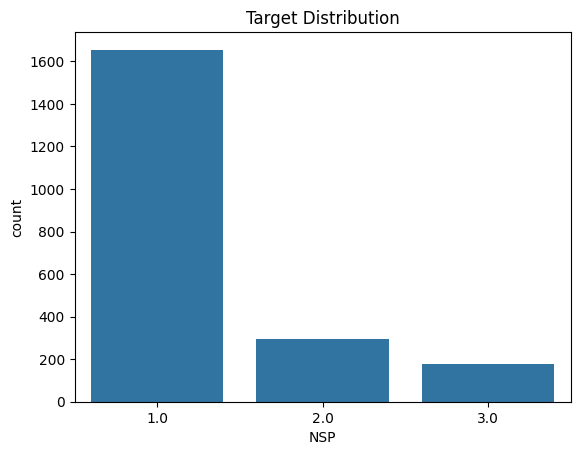

In [14]:
sns.countplot(x='NSP', data=df)
plt.title("Target Distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

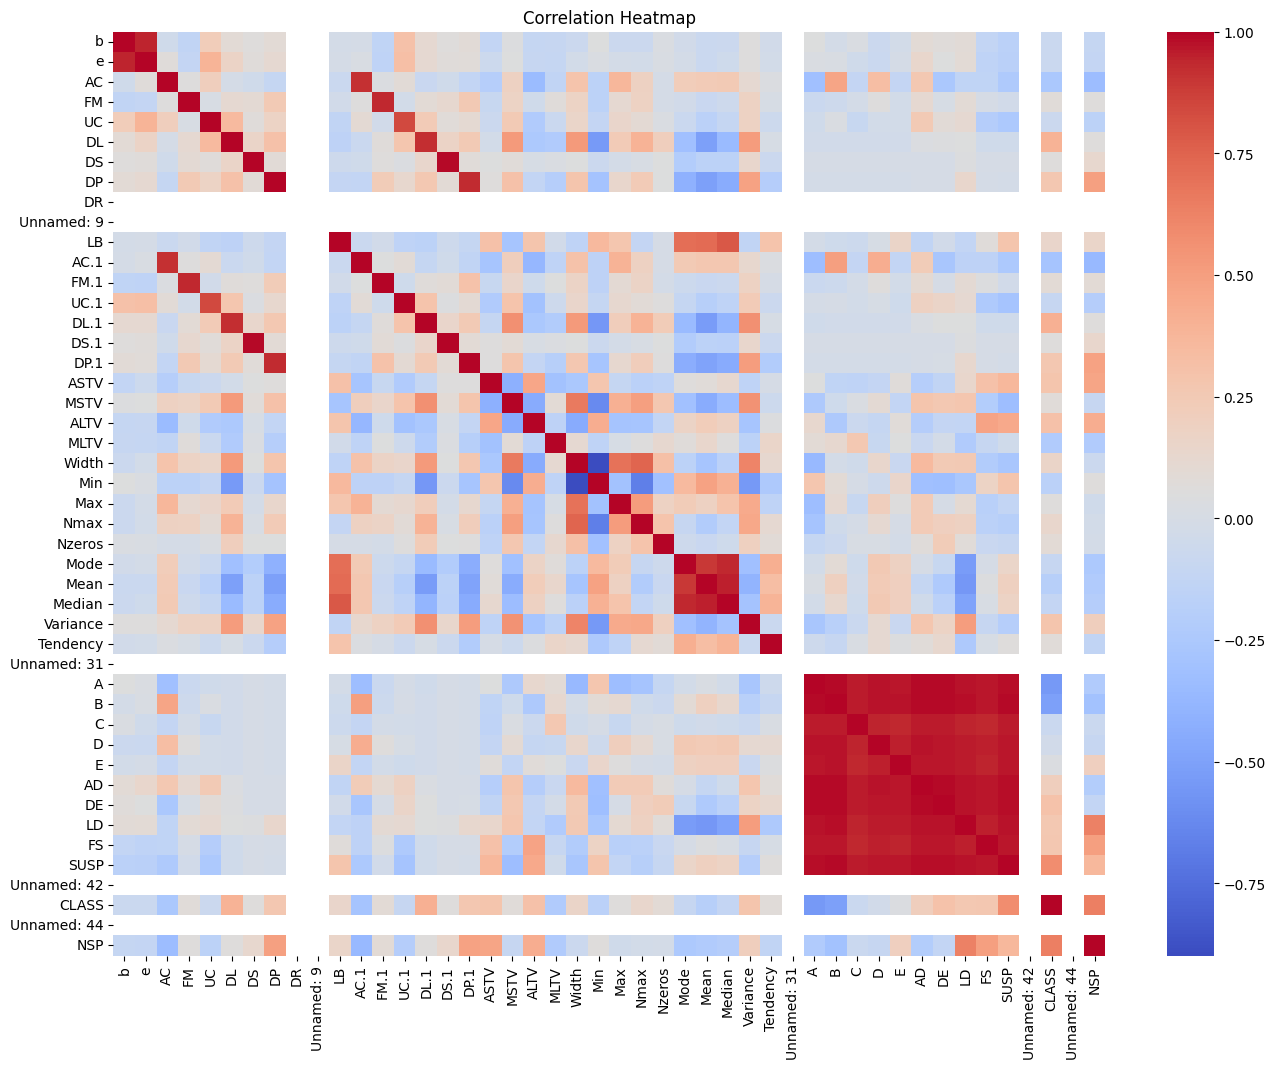

In [15]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show

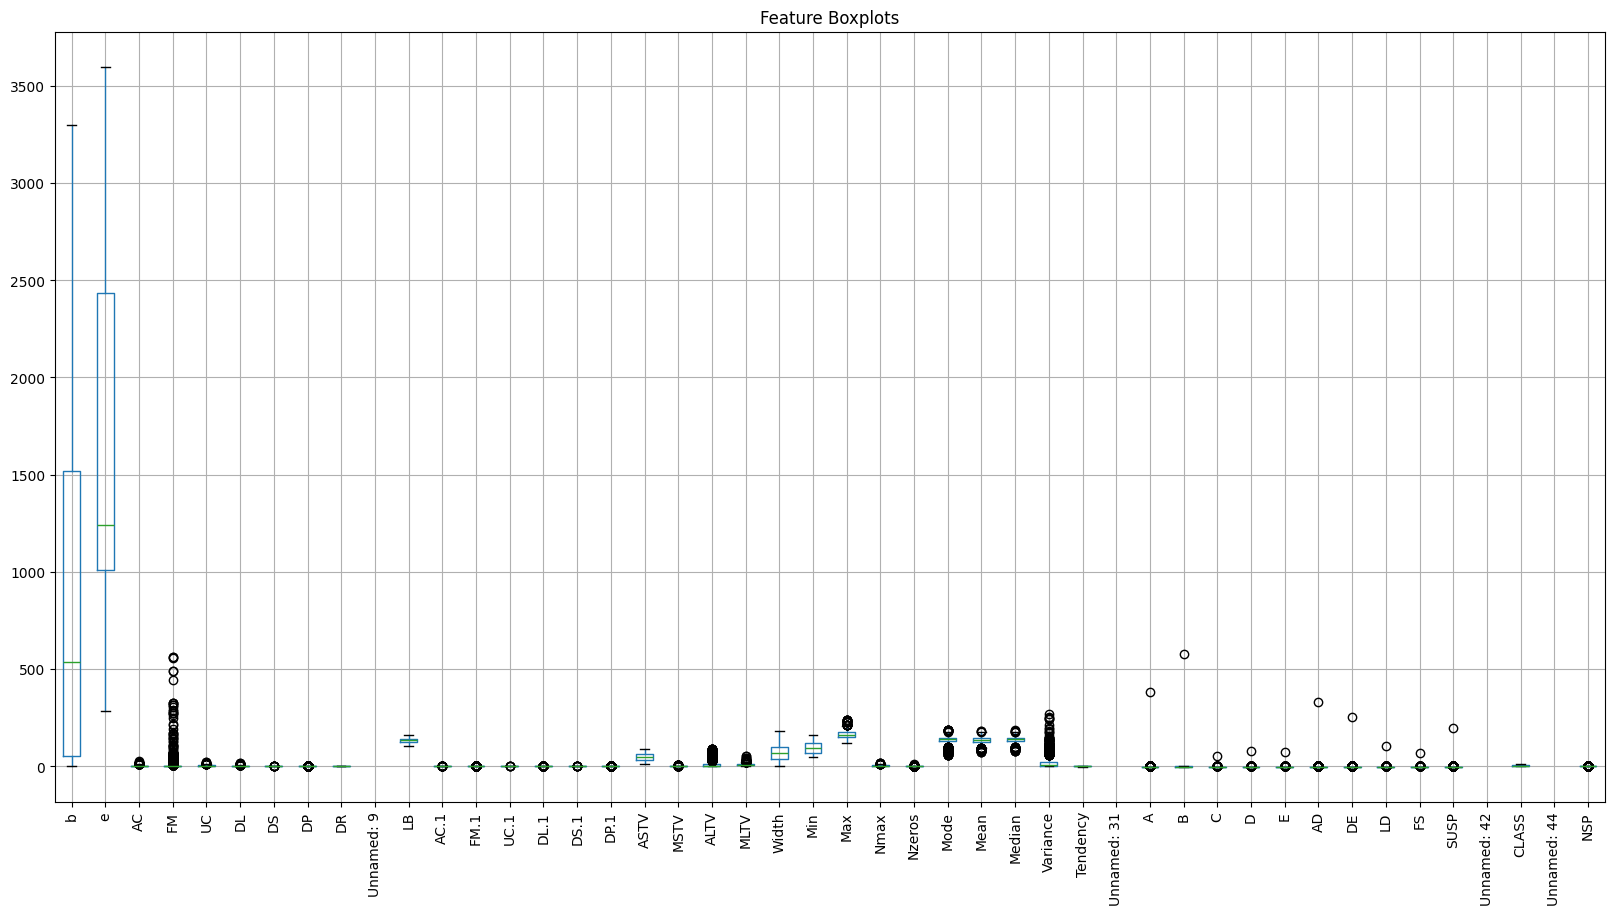

In [16]:
plt.figure(figsize=(20,10))
df.boxplot(rot=90)
plt.title("Feature Boxplots")
plt.show()

In [36]:

import pandas as pd
import numpy as np


# Clean column names
df.columns = df.columns.str.strip()

# Keep only useful columns
selected_cols = [
    'LB', 'AC', 'FM', 'UC',
    'ASTV', 'MSTV', 'ALTV', 'MLTV',
    'Width', 'Min', 'Max',
    'Nmax', 'Nzeros', 'Mode',
    'Mean', 'Median', 'Variance',
    'Tendency', 'NSP'
]

df = df[selected_cols]

# Remove rows where NSP is missing
df = df.dropna(subset=['NSP'])

# Fill remaining missing values
df = df.fillna(df.mean())

# Convert NSP to integer
df['NSP'] = df['NSP'].astype(int)

# Features and target
X = df.drop('NSP', axis=1)

y = df['NSP']

# Check shape
print(df.shape)

# Check missing values
print(df.isnull().sum())

(2126, 19)
LB          0
AC          0
FM          0
UC          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
NSP         0
dtype: int64


In [37]:
df = df.dropna(subset=['NSP'])
df['NSP'] = df['NSP'].astype(int)

In [38]:
X = df.drop('NSP', axis=1)

# Target
y = df['NSP']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [40]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [42]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


In [43]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8826291079812206
Decision Tree Accuracy: 0.8967136150234741
Random Forest Accuracy: 0.9342723004694836


In [44]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           1       0.95      0.98      0.96       332
           2       0.89      0.69      0.78        59
           3       0.88      0.86      0.87        35

    accuracy                           0.93       426
   macro avg       0.91      0.85      0.87       426
weighted avg       0.93      0.93      0.93       426



In [45]:
report = classification_report(
    y_test,
    rf_pred,
    output_dict=True
)

with open("classification_report.json", "w") as f:
    json.dump(report, f)

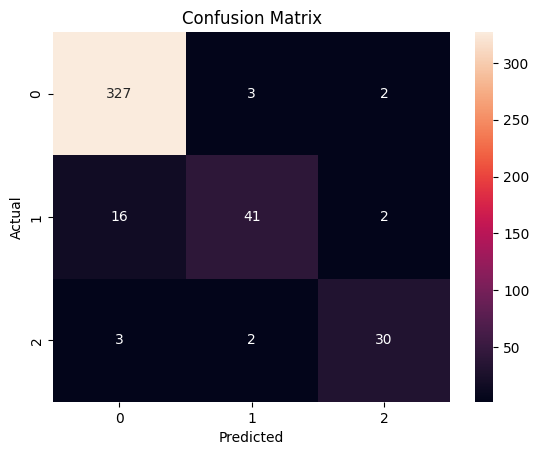

In [46]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

strat_scores = cross_val_score(
    rf,
    X,
    y,
    cv=skf
)

print("Stratified KFold Scores:")
print(strat_scores)

print("Average Stratified Score:")
print(strat_scores.mean())

Stratified KFold Scores:
[0.94835681 0.93647059 0.95529412 0.93882353 0.96235294]
Average Stratified Score:
0.9482595967964651


In [48]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))